In [ ]:
import pytest
import networkx as nx
from cyberbattle.simulation.actions_test import ENV, NODES
import cyberbattle.simulation.model as model
import cyberbattle.simulation.actions as actions
import cyberbattle.simulation.vulnerability_graph as vg
import plotly.offline as plo
from typing import (
    Iterator,
    List,
    NamedTuple,
    Optional,
    Set,
    Tuple,
    Dict,
    TypedDict,
    cast,
)
plo.init_notebook_mode(connected=True) # type: ignore
%matplotlib inline

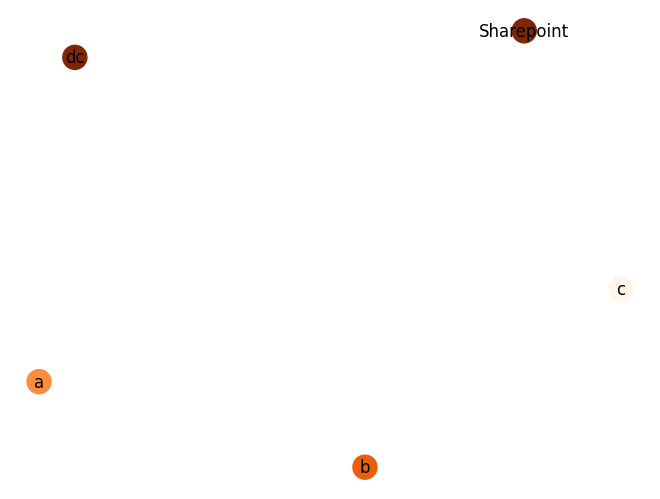

In [2]:
ENV.plot_environment_graph()

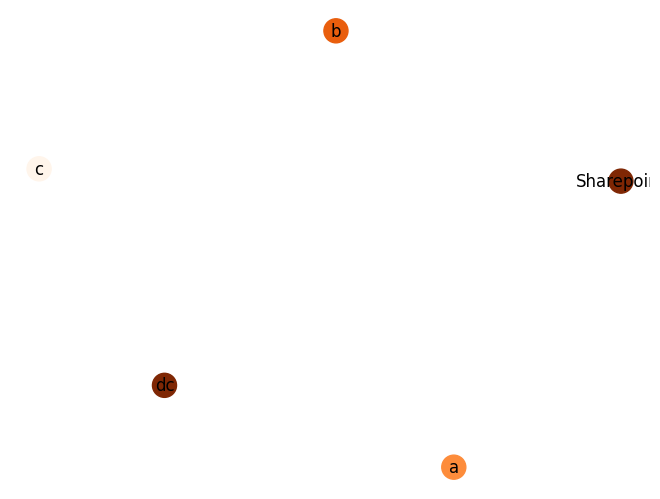

In [ ]:
attacker = actions.AgentActions(ENV)
defender = actions.DefenderAgentActions(ENV, attacker, 10)
defender._environment.plot_environment_graph()

def build_edges(nodes: List[actions.DiscoveredNodeInfo]):
    for n in [x for x in nodes if x["status"] == "owned"]:
        try:
            local_attacks = attacker.list_local_attacks(n["id"])
            for attack in local_attacks:
                if attacker.__process_outcome(model.VulnerabilityType.LOCAL, attack, n["id"],defender._environment.get_node(n["id"]), False, 0, True):
                    attacker.__annotate_edge()
        except:
